***SECTION 1***



**Buiseness Understanding** :- The telecom company is experiencing customer churn, where some customers discontinue their services. Customer churn leads to revenue loss and increases the cost of acquiring new customers. The company wants to identify customers who are likely to churn so that the customer retention team can take proactive actions to retain them.



**Buiseness Objective** :- The main objective is to develop a Machine Learning model that predicts whether a customer will churn based on their account information, service usage, calling behavior, subscription plans, and interactions with customer service.

The business aims to:

1. Predict customers at risk of leaving.
2. Understand the key factors influencing churn.
3. Help the retention team target high-risk customers.
4. Reduce customer churn and improve customer satisfaction.



**Target Variable** :- Churn


**Success Metrics** :- The performance of the Machine Learning model will be evaluated using:

1. Accuracy
2. Precision
3. Recall
4. F1-Score
5. Confusion Matrix


**Business KPIs** :- The success of the churn prediction system can be measured using the following business KPIs:

1. Customer Churn Rate
2. Customer Retention Rate
3. Revenue Saved by Retaining Customers
4. Customer Lifetime Value (CLV)
5. Percentage Reduction in Churn
6. Customer Satisfaction Score (CSAT)



**Expected Buiseness Outcome** :- After deploying the prediction model, the telecom company should be able to:

1. Identify customers with a high probability of churning.
2. Take preventive actions such as discounts, loyalty offers, or personalized support.
3. Reduce customer churn.
4. Improve customer retention.
5. Increase revenue and customer loyalty.
6. Enable data-driven decision-making for the customer retention team

In [3]:
# Section 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df =pd.read_csv("/content/dataset.csv")

#Display first records
df.head()

#Display last records
df.tail()

#Shape of dataset
df.shape

#Data types
df.dtypes

#Dataset Information
df.info()

#Memory usage
df.memory_usage(deep=True)

#Duplicate Records
df.duplicated().sum()

#Missing Values summary
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


***Section 3 :- Data Dictionary***

| Feature Name               | Data Type       | Description                                                                                       | Business Meaning                                                                                               |
| -------------------------- | --------------- | ------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| **State**                  | Object          | State in which the customer resides.                                                              | Helps analyze customer churn across different geographical regions and identify region-specific trends.        |
| **Account length**         | Integer (int64) | Number of days the customer's account has been active.                                            | Indicates customer tenure. Customers with longer account histories may be more loyal and less likely to churn. |
| **Area code**              | Integer (int64) | Telephone area code assigned to the customer.                                                     | Used to segment customers based on location for regional analysis and marketing strategies.                    |
| **International plan**     | Object          | Indicates whether the customer has subscribed to an international calling plan (Yes/No).          | Helps determine whether international service subscriptions influence customer churn.                          |
| **Voice mail plan**        | Object          | Indicates whether the customer has a voicemail service plan (Yes/No).                             | Measures adoption of value-added services, which may improve customer retention.                               |
| **Number vmail messages**  | Integer (int64) | Number of voicemail messages received or stored.                                                  | Reflects the customer's usage of voicemail services and engagement with telecom features.                      |
| **Total day minutes**      | Float (float64) | Total duration of daytime calls in minutes.                                                       | Measures customer usage during daytime and helps identify calling behavior.                                    |
| **Total day calls**        | Integer (int64) | Total number of daytime calls made by the customer.                                               | Indicates customer communication frequency during daytime hours.                                               |
| **Total day charge**       | Float (float64) | Charges incurred for daytime calls.                                                               | Represents revenue generated from daytime calling services.                                                    |
| **Total eve minutes**      | Float (float64) | Total duration of evening calls in minutes.                                                       | Measures customer usage during evening hours.                                                                  |
| **Total eve calls**        | Integer (int64) | Number of evening calls made by the customer.                                                     | Indicates evening communication frequency.                                                                     |
| **Total eve charge**       | Float (float64) | Charges incurred for evening calls.                                                               | Represents revenue generated from evening telecom services.                                                    |
| **Total night minutes**    | Float (float64) | Total duration of nighttime calls in minutes.                                                     | Measures customer service usage during nighttime hours.                                                        |
| **Total night calls**      | Integer (int64) | Number of nighttime calls made by the customer.                                                   | Helps understand customer calling behavior at night.                                                           |
| **Total night charge**     | Float (float64) | Charges incurred for nighttime calls.                                                             | Represents revenue earned from nighttime services.                                                             |
| **Total intl minutes**     | Float (float64) | Total duration of international calls in minutes.                                                 | Measures customer usage of international calling services.                                                     |
| **Total intl calls**       | Integer (int64) | Number of international calls made by the customer.                                               | Indicates how frequently the customer makes international calls.                                               |
| **Total intl charge**      | Float (float64) | Charges incurred for international calls.                                                         | Represents revenue generated through international telecom services.                                           |
| **Customer service calls** | Integer (int64) | Number of times the customer contacted customer service.                                          | A high number of service calls may indicate customer dissatisfaction and a higher probability of churn.        |
| **Churn**                  | Boolean (bool)  | Indicates whether the customer discontinued the telecom service (True = Churn, False = No Churn). | **Target variable** used to predict whether a customer is likely to leave the company.                         |


In [4]:
#Section 4

# 1. Duplicate Handling
df.duplicated().sum()
# Output :- There are no duplicates available

# 2. Missing Value Treatment
df.isnull().sum()
# Output :- There are no missing values available




,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [5]:
# 3. Outlier Detection (using IQR)
Q1 = df["Total day minutes"].quantile(0.25)
Q3 = df["Total day minutes"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Total day minutes"] < lower_limit) |
    (df["Total day minutes"] > upper_limit)
]

print(outliers)

     State  Account length  Area code International plan Voice mail plan  \
128     OH              83        415                 No              No   
296     CO             154        415                 No              No   
485     MO             112        415                 No              No   
540     CO              63        415                 No             Yes   
582     NE              66        415                 No              No   
780     NY              64        415                Yes              No   
833     OR              98        415                Yes              No   
1057    SD              98        415                 No              No   
1100    VT             101        510                 No              No   
1285    SC             138        510                 No             Yes   
1333    OK              82        510                 No              No   
1575    WI              70        415                 No              No   
1612    SD  

A good approach is:

1. Detect outliers using the IQR method.
2. Visualize them with boxplots.
3. Decide whether they are realistic.
4. If they are valid customer behaviors, keep them.
5. If they are errors or have an excessive influence on the model, apply capping instead of removing them.

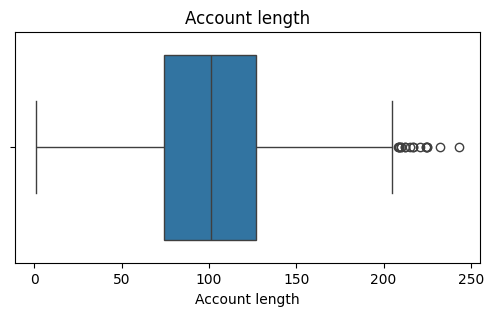

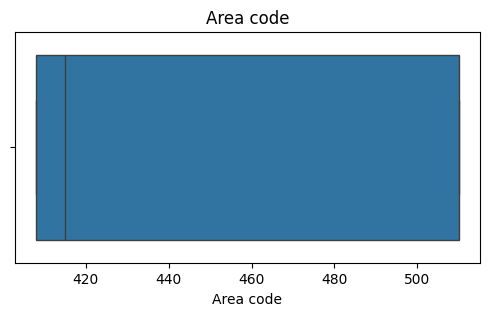

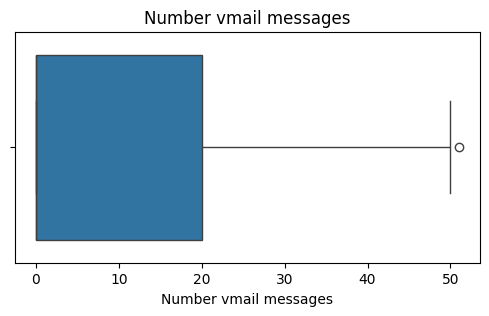

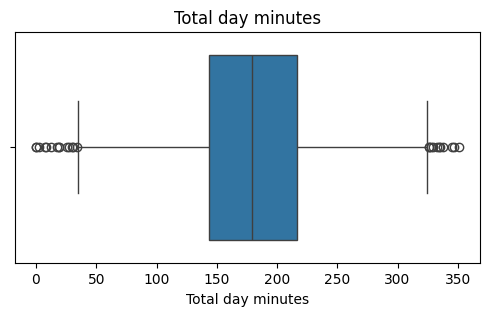

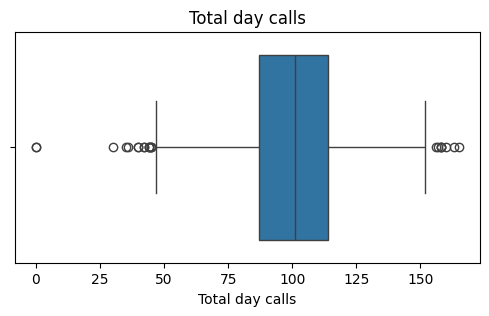

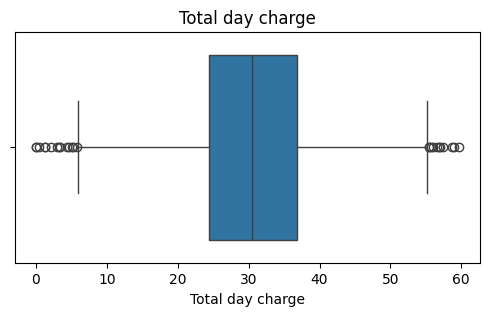

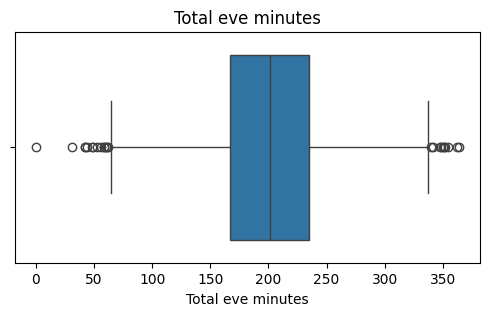

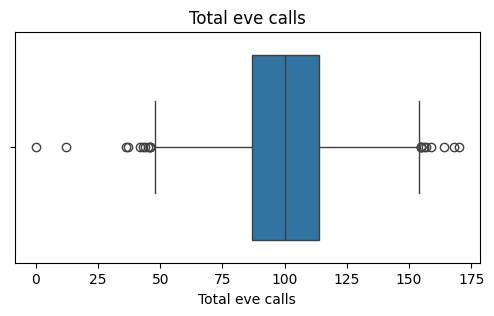

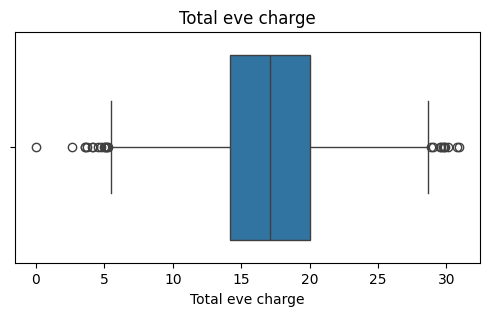

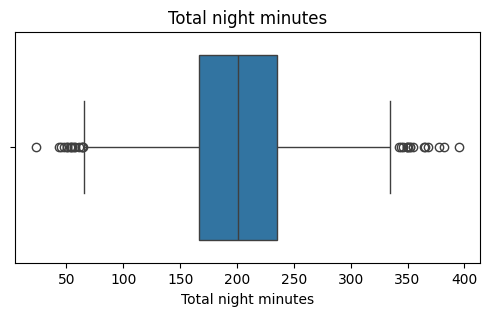

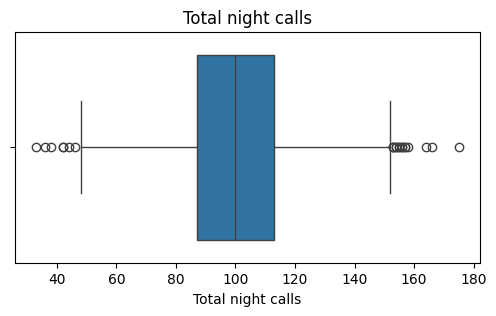

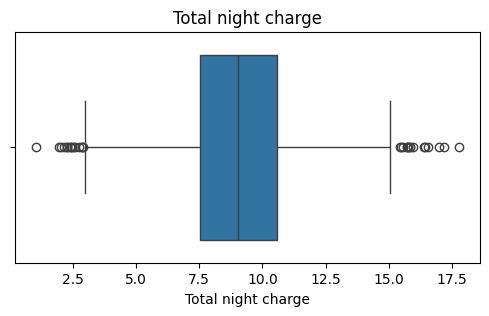

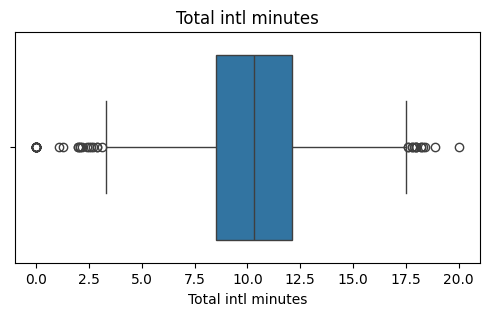

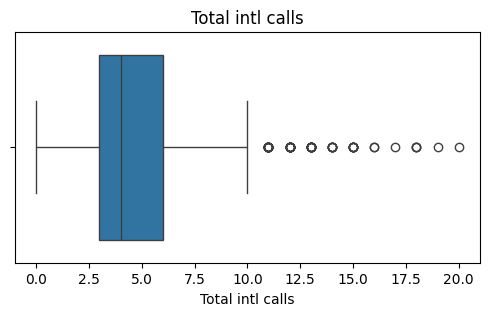

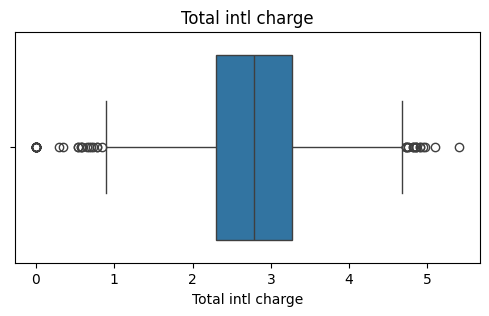

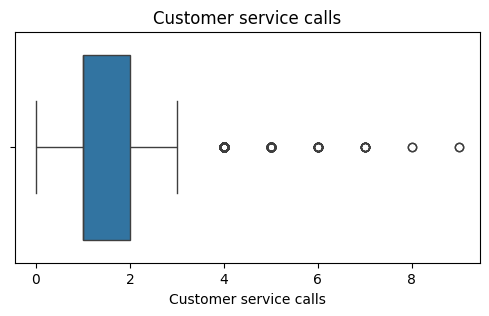

In [6]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [7]:
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[column] = data[column].clip(lower, upper)

    return data

In [8]:
for col in numeric_cols:
    df = cap_outliers(df, col)


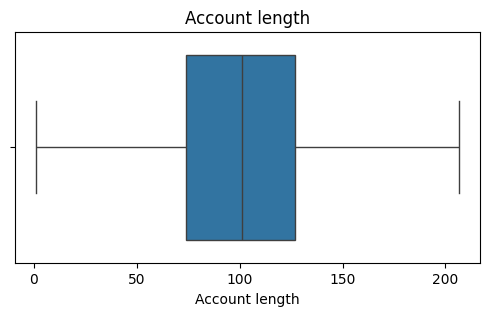

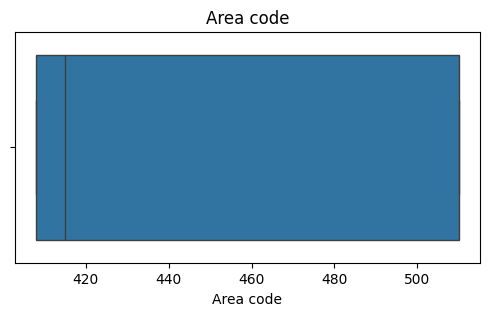

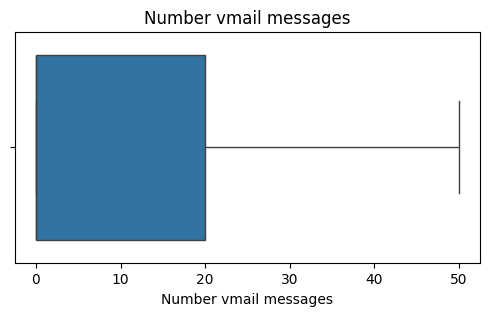

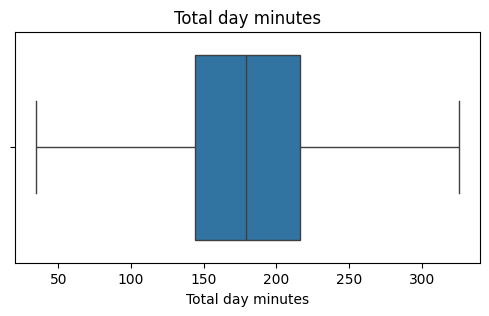

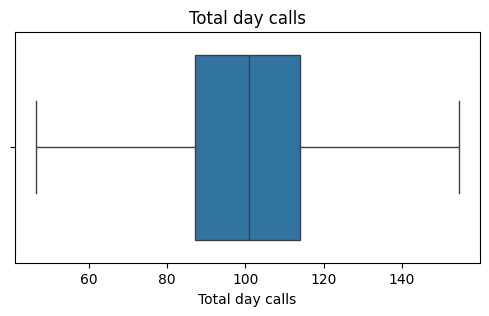

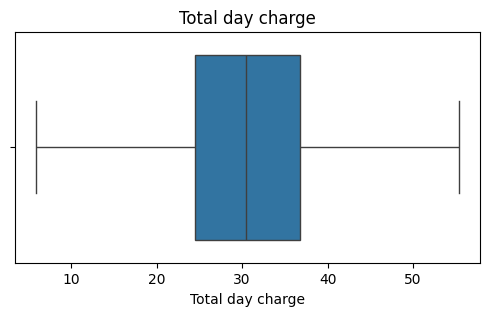

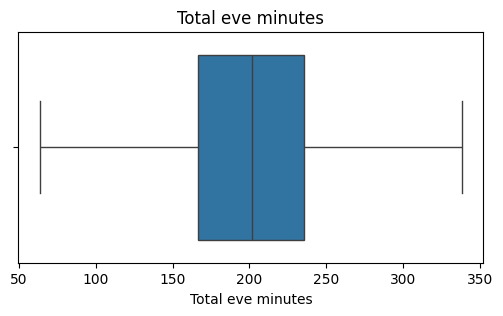

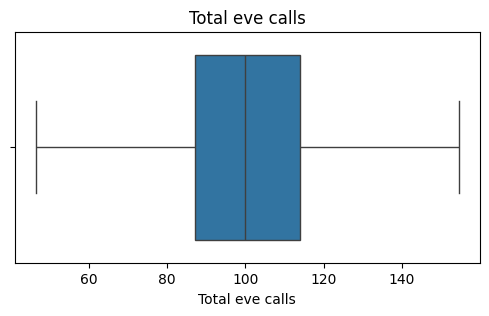

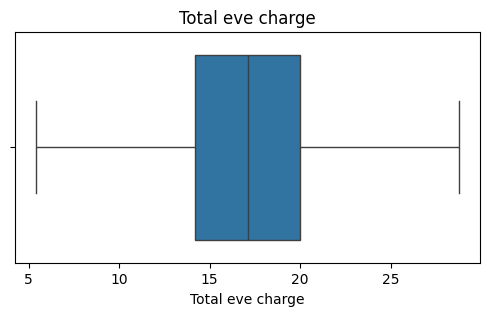

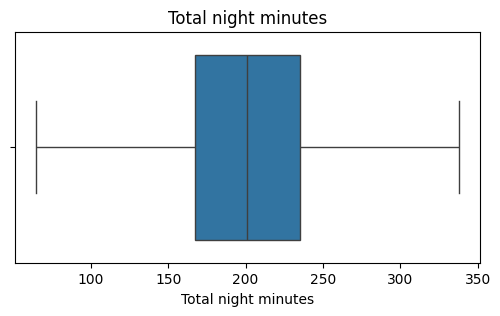

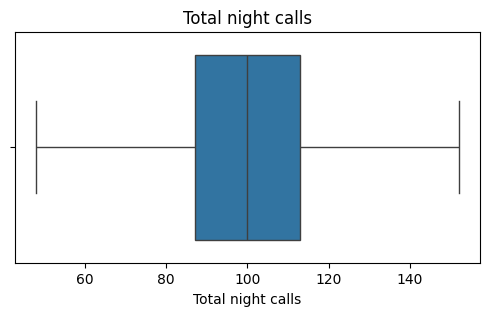

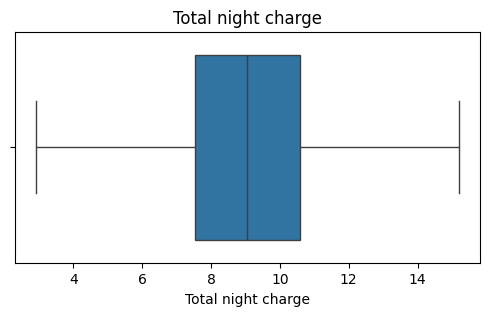

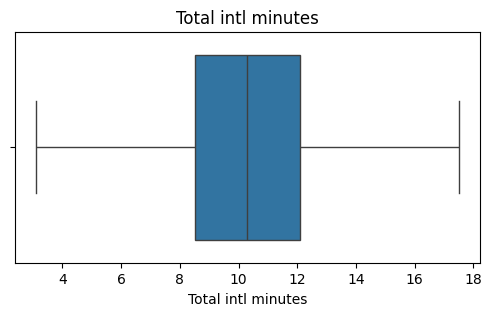

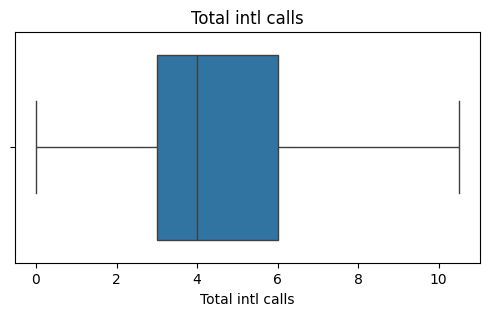

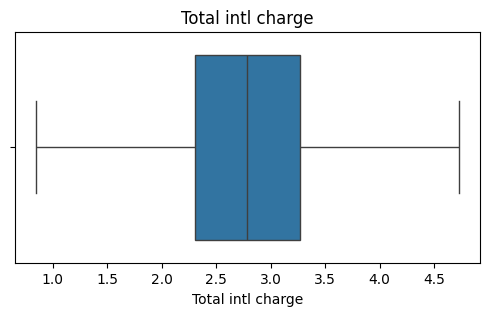

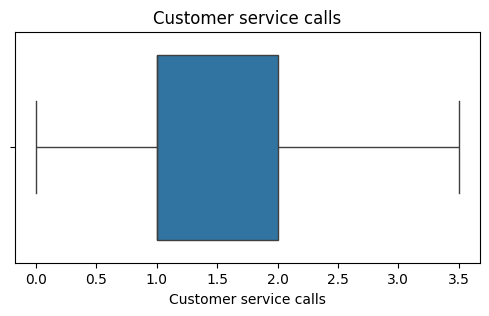

In [9]:
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

**Outlier Detection** :- Outliers were detected using the Interquartile Range (IQR) method and visualized using boxplots for all numerical features.



**Outlier Treatment** :- Since the dataset contains customer usage information, many extreme values represent genuine customer behavior rather than data errors. Therefore, outliers were not removed. Where necessary, the IQR capping (winsorization) technique was applied to limit the influence of extreme values while preserving all customer records for model training.

***Data Validation (Its purpose is to ensure that the data does not contain invalid values, incorrect data types, or inconsistent records.)***


| Invalid Data                   | Why it's Incorrect                           |
| ------------------------------ | -------------------------------------------- |
| Account length = -20           | Number of days cannot be negative.           |
| Total day minutes = -50        | Call duration cannot be negative.            |
| Churn = "Maybe"                | The target should only be `True` or `False`. |
| International plan = "Unknown" | Only valid values should be `Yes` or `No`.   |


In [10]:
#Check data types
df.dtypes
df.info()

#Check missing values
df.isnull().sum()

#Check duplicate records
df.duplicated().sum()

#Check unique values
df.nunique()

#Check Value Ranges
df.describe()

#Check for negative values
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
(df[numeric_cols] < 0).sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   float64
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   float64
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   float64
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

,0
Account length,0
Area code,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0
Total eve calls,0
Total eve charge,0
Total night minutes,0


| Validation Check                          | Code                                | Status |
| ----------------------------------------- | ----------------------------------- | ------ |
| Data Types                                | `df.info()`                         | ✓      |
| Missing Values                            | `df.isnull().sum()`                 | ✓      |
| Duplicate Records                         | `df.duplicated().sum()`             | ✓      |
| Summary Statistics                        | `df.describe()`                     | ✓      |
| Unique Categories                         | `df['column'].unique()`             | ✓      |
| Negative Values                           | `(df[numeric_cols] < 0).sum()`      | ✓      |
| Logical Consistency (minutes vs. charges) | Compare minutes × rate with charges | ✓      |


**Section 5**

In [11]:
# KPI 1: Customer Churn Rate
churn_rate = (df["Churn"].sum() / len(df)) * 100
print(f"Churn Rate: {churn_rate:.2f}%")

# KPI 2: Average Customer Revenue
df["Total Revenue"] = (
    df["Total day charge"] +
    df["Total eve charge"] +
    df["Total night charge"] +
    df["Total intl charge"]
)

avg_revenue = df["Total Revenue"].mean()
print("Average Revenue : " , avg_revenue)

# KPI 3: Average Customer Usage
df["Total Minutes"] = (
    df["Total day minutes"] +
    df["Total eve minutes"] +
    df["Total night minutes"] +
    df["Total intl minutes"]
)

df["Total Minutes"].mean()

Churn Rate: 14.49%
Average Revenue :  59.462008700870086


np.float64(591.9084158415842)

Section 6

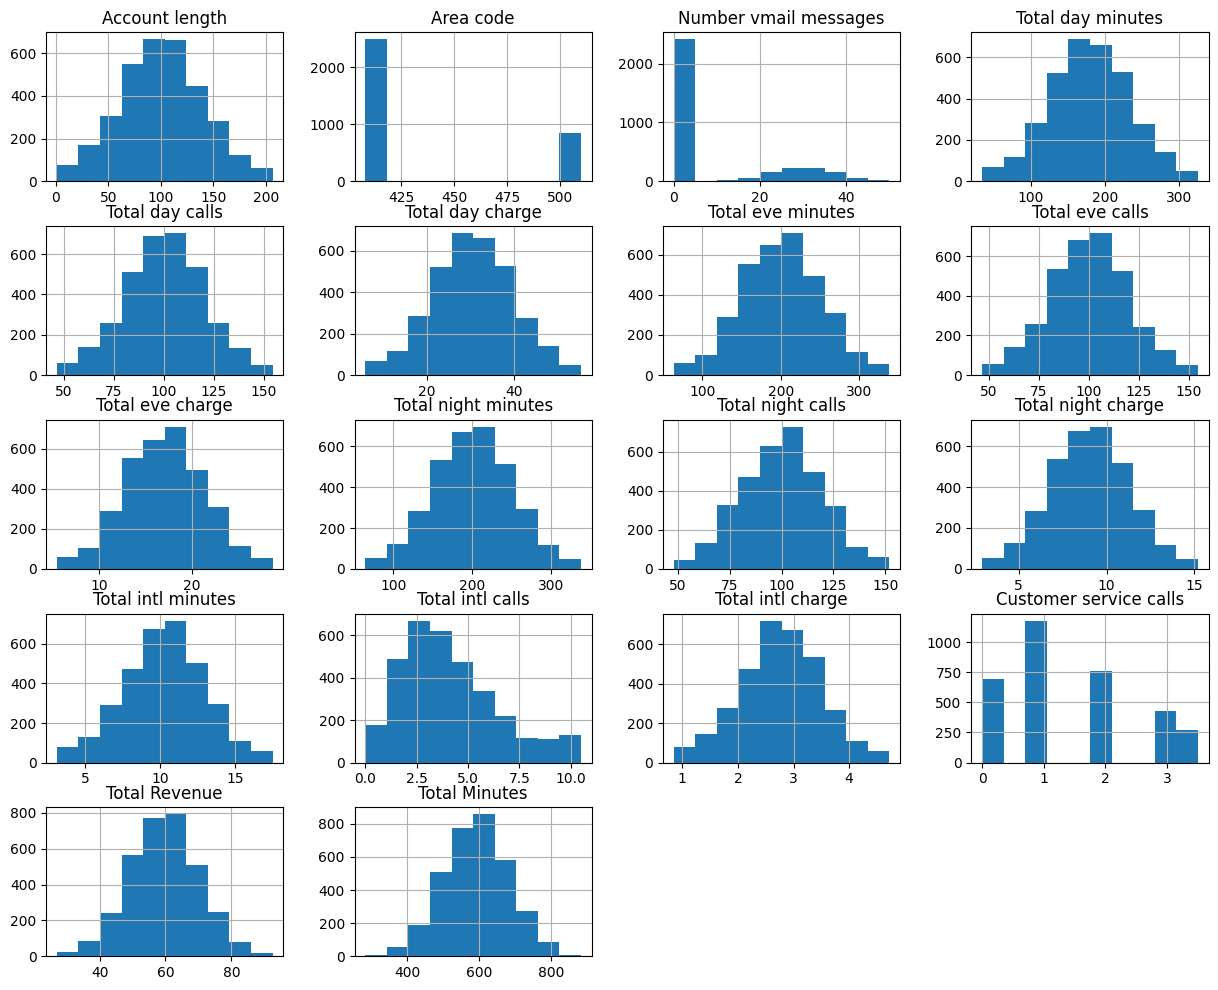

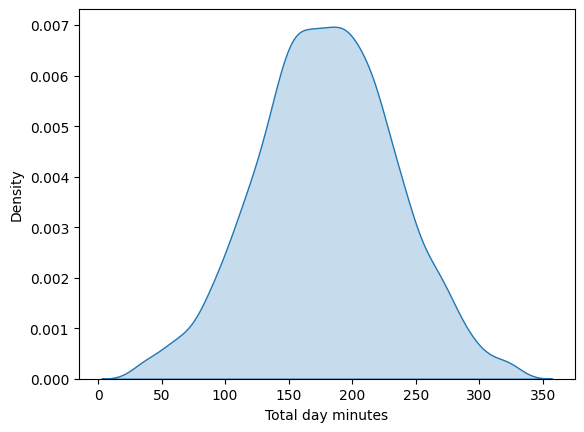

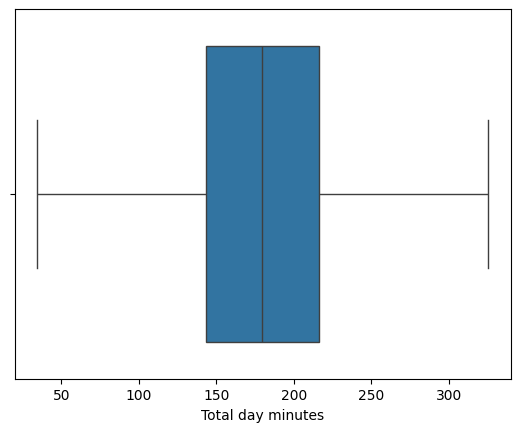

In [12]:
#Numerical Analaysis

# 1. Histogram (Interpretation - Most numerical features show different distributions, helping identify skewness and customer usage patterns.)
df.hist(figsize=(15,12))
plt.show()

# 2. KDE plot (Interpretation - Shows the probability density of daytime call minutes and helps identify concentration of customer usage.)
sns.kdeplot(df["Total day minutes"], fill=True)
plt.show()

# 3. Box plot (Interpretation - Used to identify the spread of data and detect outliers.)
sns.boxplot(x=df["Total day minutes"])
plt.show()

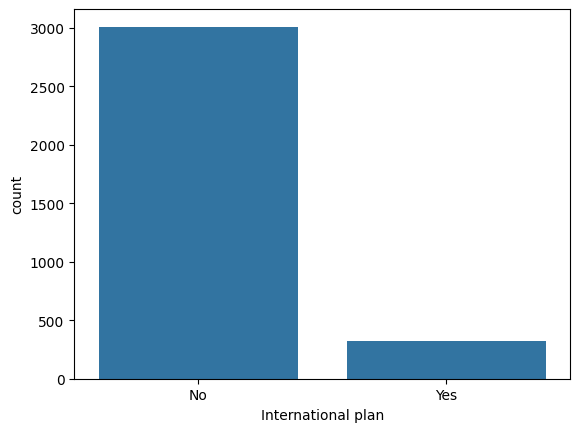

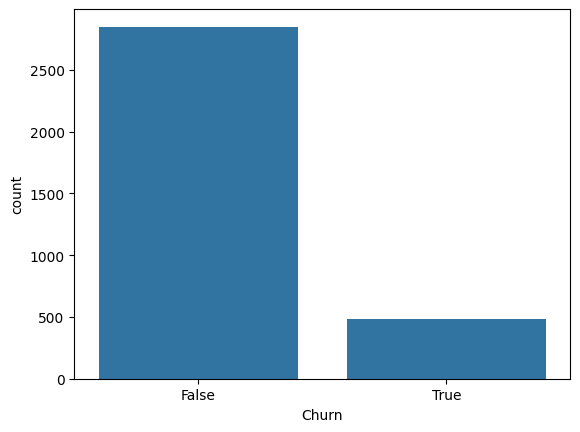

In [13]:
#Categorical Analysis


# 1. Count plot (Interpretation - Displays the distribution of customers subscribed to the international plan.)
sns.countplot(x="International plan", data=df)
plt.show()

# 2. Churn Distribution (Interpretation - The dataset is imbalanced, with more customers staying than leaving.)
sns.countplot(x="Churn", data=df)
plt.show()

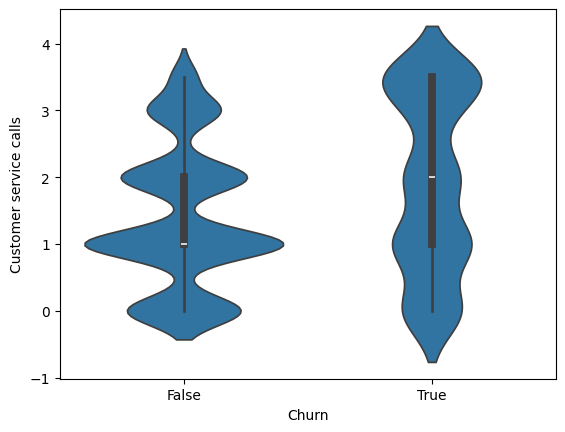

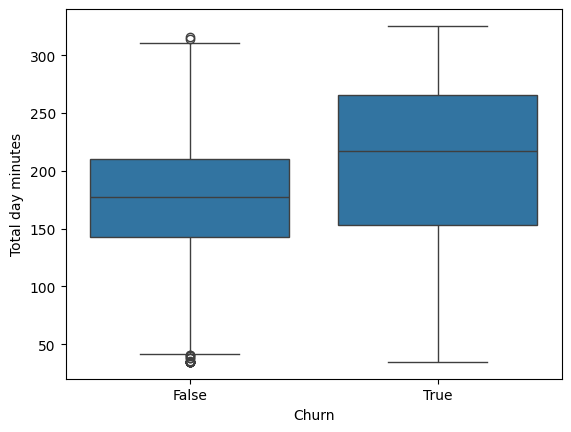

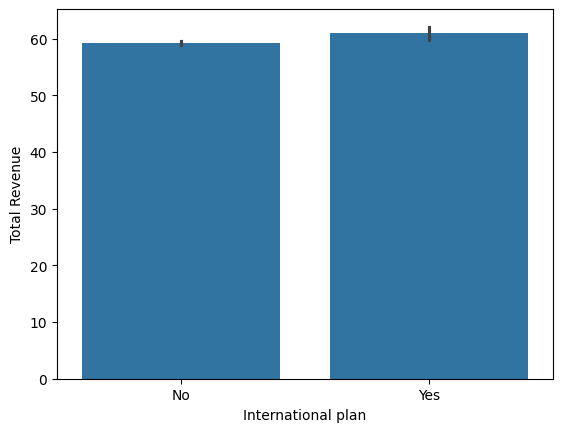

Churn,False,True
International plan,,
No,2664,346
Yes,186,137


In [14]:
#Bivariate Analysis

# 1. Violin plot (Interpretation - Customers with more customer service calls may exhibit a higher churn tendency.)
sns.violinplot(x="Churn", y="Customer service calls", data=df)
plt.show()

# 2. Box plot (Interpretation - Compare daytime usage between churned and retained customers.)
sns.boxplot(x="Churn", y="Total day minutes", data=df)
plt.show()

# 3. Bar plot (Interpretation - Compare revenue across different subscription plans )
sns.barplot(x="International plan",
            y="Total Revenue",
            data=df)
plt.show()

# 4. Grouped Analysis (Interpretation - Shows how churn varies across different service plans)
pd.crosstab(df["International plan"], df["Churn"])

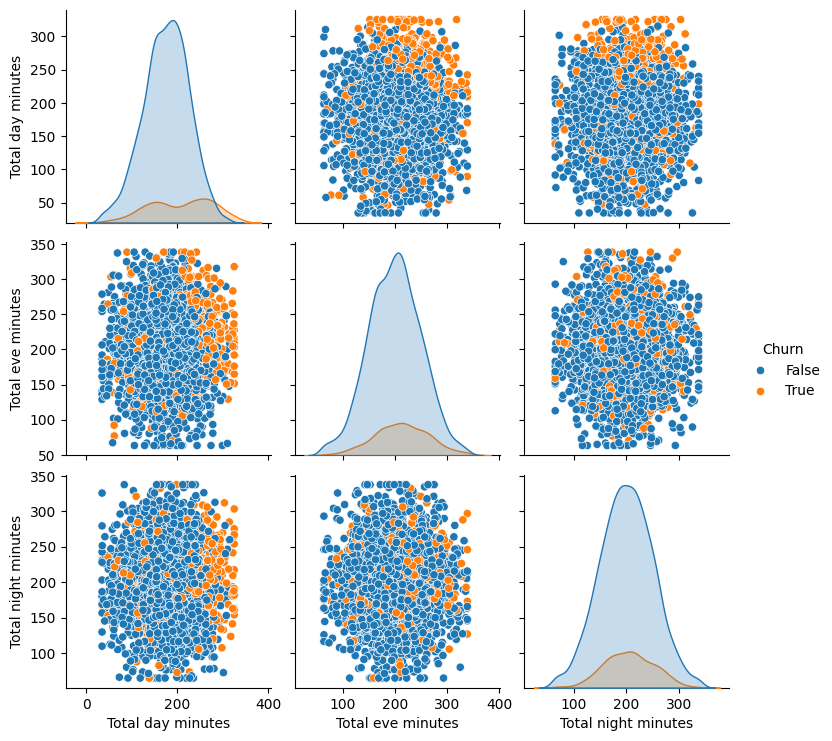

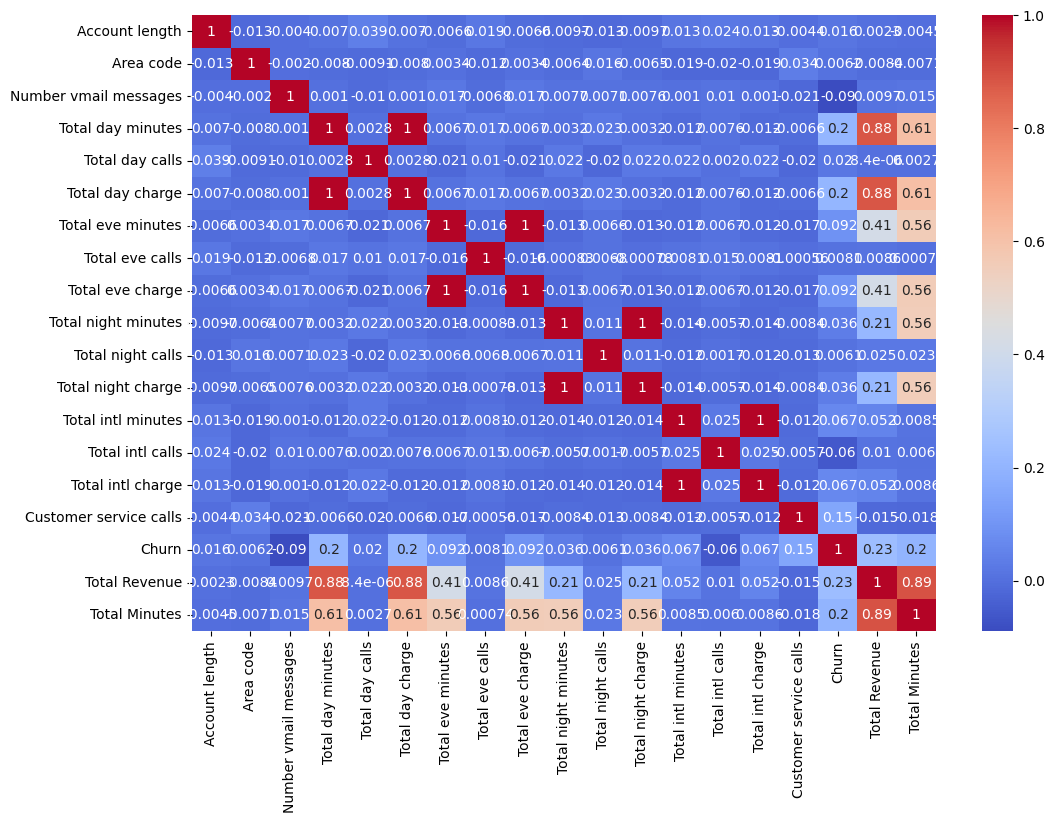

Churn,False,True
Voice mail plan,,
No,0.832849,0.167151
Yes,0.913232,0.086768


In [15]:
# Multivariate Analysis

# 1. Pair plot (Interpretation - Helps visualize relationships among multiple numerical features. )
sns.pairplot(df[[
    "Total day minutes",
    "Total eve minutes",
    "Total night minutes",
    "Churn"
]], hue="Churn")

# 2. Corelation Heatmap (Interpretation - Identifies relationships between numerical variables.)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

# 3. Cross-tab Analysis (Interpretation - Compares churn percentages across voicemail plan categories.)
pd.crosstab(df["Voice mail plan"], df["Churn"], normalize="index")

Section 7: Feature Engineering (Create meaningful business features.)

In [16]:
# 1. Total minutes
df["Total Minutes"] = (
    df["Total day minutes"] +
    df["Total eve minutes"] +
    df["Total night minutes"] +
    df["Total intl minutes"]
)

# 2. Total revenue
df["Total Revenue"] = (
    df["Total day charge"] +
    df["Total eve charge"] +
    df["Total night charge"] +
    df["Total intl charge"]
)

# 3. Revenue per minute
df["Revenue Per Minute"] = (
    df["Total Revenue"] /
    df["Total Minutes"]
)

# 4. Customer loyalty
df["Customer Loyalty"] = (
    df["Account length"] / 365
)

# 5. Service Call ratio
df["Service Call Ratio"] = (
    df["Customer service calls"] /
    (df["Account length"] + 1)
)

Section 8: Feature Encoding (Identify categorical columns and convert them into the numerical columns because at last machine is only able to understand numerical values instead of categories.)

In [17]:
categorical = df.select_dtypes(include="object").columns
print(categorical)

#Label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["International plan"] = le.fit_transform(df["International plan"])
df["Voice mail plan"] = le.fit_transform(df["Voice mail plan"])


#One-hot encoding
df = pd.get_dummies(df,columns=["State"],drop_first=True)


Index(['State', 'International plan', 'Voice mail plan'], dtype='object')


Section 9: Feature Selection

**(Removed Features)**

Some features are almost exact calculations of others:
1. Total day charge
2. Total eve charge
3. Total night charge
4. Total intl charge

Since:

Charge = Minutes × Fixed Rate

they provide almost the same information as the corresponding minutes and can introduce multicollinearity.

**(Selected Features)**

Examples:
1. Account length
2. International plan
3. Voice mail plan
4. Number vmail messages
5. Total day minutes
6. Total day calls
7. Total eve minutes
8. Total eve calls
9. Total night minutes
10. Total night calls
11. Total intl minutes
12. Total intl calls
13. Customer service calls
14. Total Minutes (engineered)
15. Total Revenue (engineered)
16. Revenue Per Minute (engineered)
17. Customer Loyalty (engineered)
18. Service Call Ratio (engineered)



**(Potential Data Leakage Prevention)**

Data leakage occurs when the model learns from information that would not be available at prediction time.

For our dataset:

1. Avoid using engineered features that directly depend on the target (Churn).
2. Ensure Churn is used only as the target variable, never as an input feature.
3. Remove highly redundant variables (such as charge columns if the corresponding minute columns are retained) to reduce multicollinearity and simplify the model.

**Section 10: Feature Scaling**

What is Feature Scaling?
- Feature scaling is the process of transforming numerical features so they are on a similar scale. This prevents features with larger values from dominating those with smaller values.

Why is Feature Scaling Required?
- Some machine learning algorithms calculate distance or gradients. Features with larger magnitudes can dominate the learning process.

**Scaling Techniques**
1. StandardScaler
2. MinMaxScaler

**Which Model requires Scaling ?**

| Model               | Scaling Required? |
| ------------------- | ----------------- |
| Logistic Regression | ✅ Yes             |
| KNN                 | ✅ Yes             |
| SVM                 | ✅ Yes             |
| Neural Networks     | ✅ Yes             |
| PCA                 | ✅ Yes             |


In [21]:
#Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_standard = scaler.fit_transform(X)

#Min Max Scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_minmax = scaler.fit_transform(X)

**Section 11: Class Imbalance Analysis**

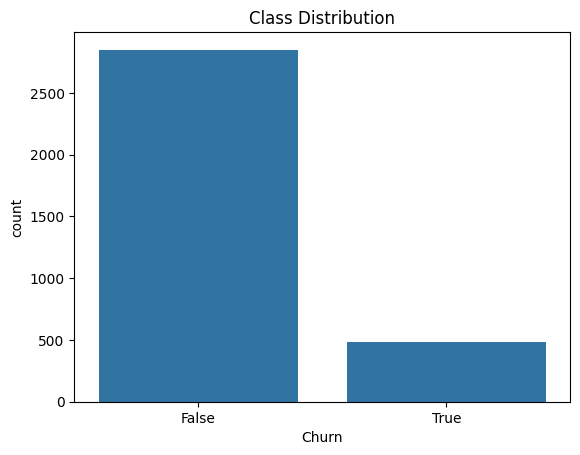

,proportion
Churn,
False,85.508551
True,14.491449


In [22]:
# Step 1 :- Check Class Distribution
df["Churn"].value_counts()

# Step 2 :- Visualise
sns.countplot(x="Churn", data=df)

plt.title("Class Distribution")
plt.show()


# Step 3 :- Percentage
(df["Churn"].value_counts(normalize=True))*100


**Report**

The target variable is imbalanced, with significantly more non-churn customers than churn customers. Therefore, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be emphasized instead of relying solely on Accuracy.

**Section 12: Train-Test Split**

Why Split the Dataset?

Machine learning models should be evaluated on unseen data to estimate how well they generalize.

1. Training Set: Used to learn patterns.
2. Testing Set: Used only for final evaluation.

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Section 13 :- MAchine Learning Models

In [24]:
#Model 1 - Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

# Train
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Probability Prediction
y_prob = model.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
# Model 2 :- Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
# Train
dt.fit(X_train, y_train)

# Prediction
y_pred_dt = dt.predict(X_test)

# Probability Prediction
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [26]:
# Model 3 :- KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(X_train, y_train)

# Prediction
y_pred_knn = knn.predict(X_test)

# Probability Prediction
y_prob_knn = knn.predict_proba(X_test)[:,1]

Section 14: Model Evaluation


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

def evaluate_model(model_name, y_test, y_pred, y_prob):

    print("="*50)
    print(model_name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC AUC  :", roc_auc_score(y_test, y_prob))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))


evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred,
    y_prob
)

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt,
    y_prob_dt
)

evaluate_model(
    "KNN",
    y_test,
    y_pred_knn,
    y_prob_knn
)

Logistic Regression
Accuracy : 0.8620689655172413
Precision: 0.7777777777777778
Recall   : 0.07216494845360824
F1 Score : 0.1320754716981132
ROC AUC  : 0.7207089889672634

Confusion Matrix
[[568   2]
 [ 90   7]]
Decision Tree
Accuracy : 0.9460269865067467
Precision: 0.7747747747747747
Recall   : 0.8865979381443299
F1 Score : 0.8269230769230769
ROC AUC  : 0.9213691445107614

Confusion Matrix
[[545  25]
 [ 11  86]]
KNN
Accuracy : 0.856071964017991
Precision: 0.5128205128205128
Recall   : 0.20618556701030927
F1 Score : 0.29411764705882354
ROC AUC  : 0.6773648037619822

Confusion Matrix
[[551  19]
 [ 77  20]]


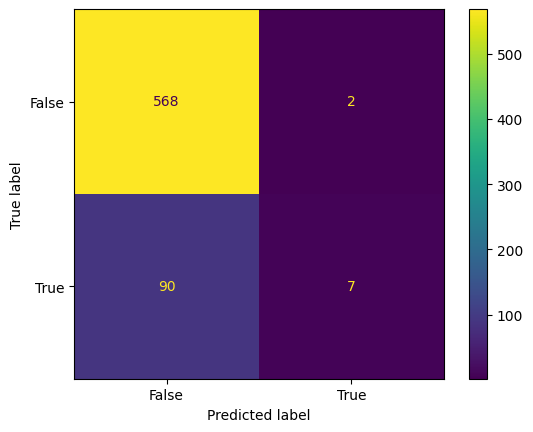

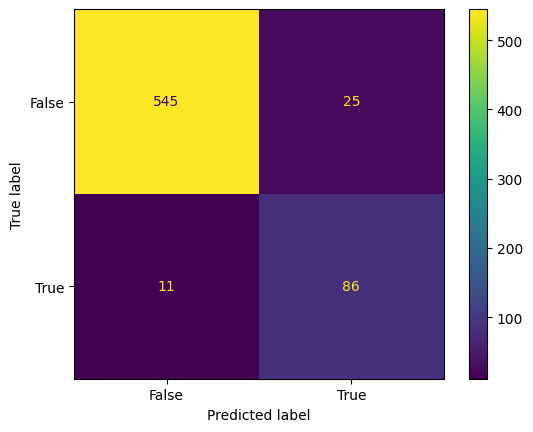

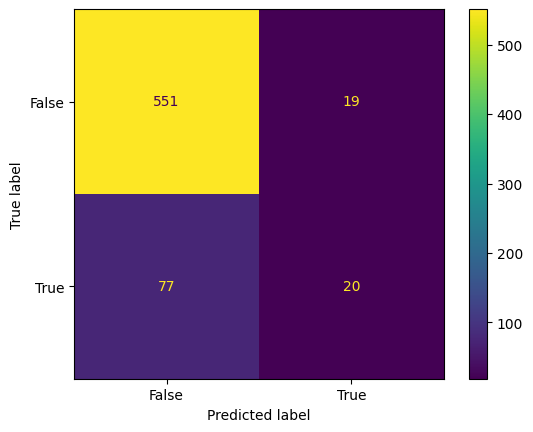

In [28]:
# Confusion Matrix

#Logistic Regression
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

#Decision Tree
ConfusionMatrixDisplay.from_estimator(
    dt,
    X_test,
    y_test
)

#KNN
ConfusionMatrixDisplay.from_estimator(
    knn,
    X_test,
    y_test
)

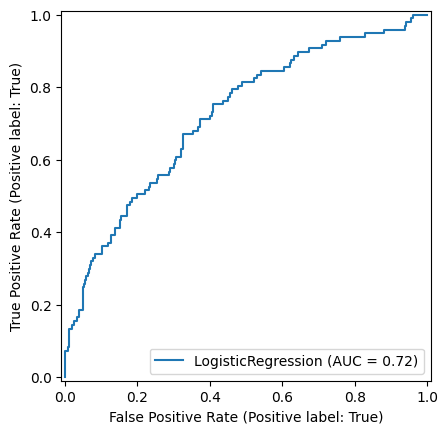

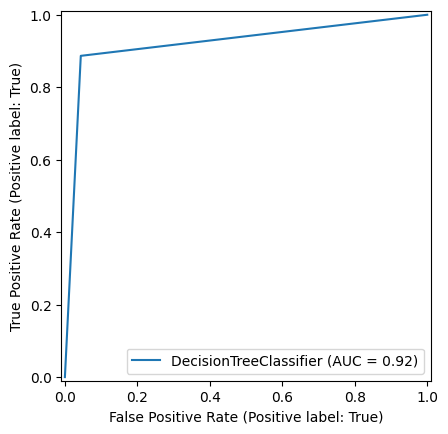

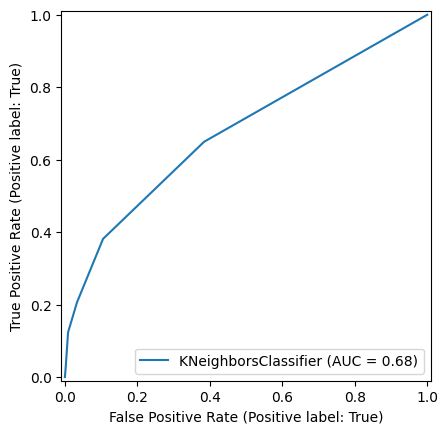

In [29]:
#ROC Curve

# Logistic Regression
RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

#Decision Tree
RocCurveDisplay.from_estimator(
    dt,
    X_test,
    y_test
)

#KNN
RocCurveDisplay.from_estimator(
    knn,
    X_test,
    y_test
)

In [30]:
# Comparison Table
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "KNN"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_knn)
    ],

    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_knn)
    ],

    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_knn)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred),
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_knn)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,y_prob),
        roc_auc_score(y_test,y_prob_dt),
        roc_auc_score(y_test,y_prob_knn)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.862069,0.777778,0.072165,0.132075,0.720709
1,Decision Tree,0.946027,0.774775,0.886598,0.826923,0.921369
2,KNN,0.856072,0.512821,0.206186,0.294118,0.677365


Section 15: Model Persistence
(Save the best model.)

| Metric    | Logistic Regression | Decision Tree |    KNN |               Best               |
| --------- | ------------------: | ------------: | -----: | :------------------------------: |
| Accuracy  |              0.8621 |    **0.9460** | 0.8561 |          ✅ Decision Tree         |
| Precision |          **0.7778** |        0.7748 | 0.5128 | ✅ Logistic Regression (slightly) |
| Recall    |              0.0722 |    **0.8866** | 0.2062 |          ✅ Decision Tree         |
| F1 Score  |              0.1321 |    **0.8269** | 0.2941 |          ✅ Decision Tree         |
| ROC-AUC   |              0.7207 |    **0.9214** | 0.6774 |          ✅ Decision Tree         |


**Conclusion**

The Decision Tree Classifier is the best model because it has:

✅ Highest Accuracy (94.60%)

✅ Highest Recall (88.66%)

✅ Highest F1 Score (82.69%)

✅ Highest ROC-AUC (92.14%)

# Section 15 :- Hyperparameter Tuning




In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Baseline Accuracy : {dt_accuracy:.4f}")

Baseline Accuracy : 0.9460


In [33]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"]
}

param_grid

{'criterion': ['gini', 'entropy'],
 'max_depth': [3, 5, 10, 15, None],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 4],
 'max_features': [None, 'sqrt', 'log2']}

# Grid Search

In [34]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [35]:
print("Best Parameters")
print(grid_search.best_params_)

print("\nBest Cross Validation Score")
print(round(grid_search.best_score_,4))

Best Parameters
{'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross Validation Score
0.9756


In [36]:
#Tuned Decision Tree
best_dt = grid_search.best_estimator_
pred_tuned = best_dt.predict(X_test)
tuned_accuracy = accuracy_score(y_test, pred_tuned)

print("Test Accuracy :", round(tuned_accuracy,4))

Test Accuracy : 0.9805


# Comparison of baseline vs tuned model


In [38]:
tuning_comparison = pd.DataFrame({

    "Model":[
        "Baseline Decision Tree",
        "Tuned Decision Tree"
    ],

    "Accuracy":[
        dt_accuracy,
        tuned_accuracy
    ]
})

tuning_comparison

,Model,Accuracy
0,Baseline Decision Tree,0.946027
1,Tuned Decision Tree,0.980510


# Visualising base vs tuned model

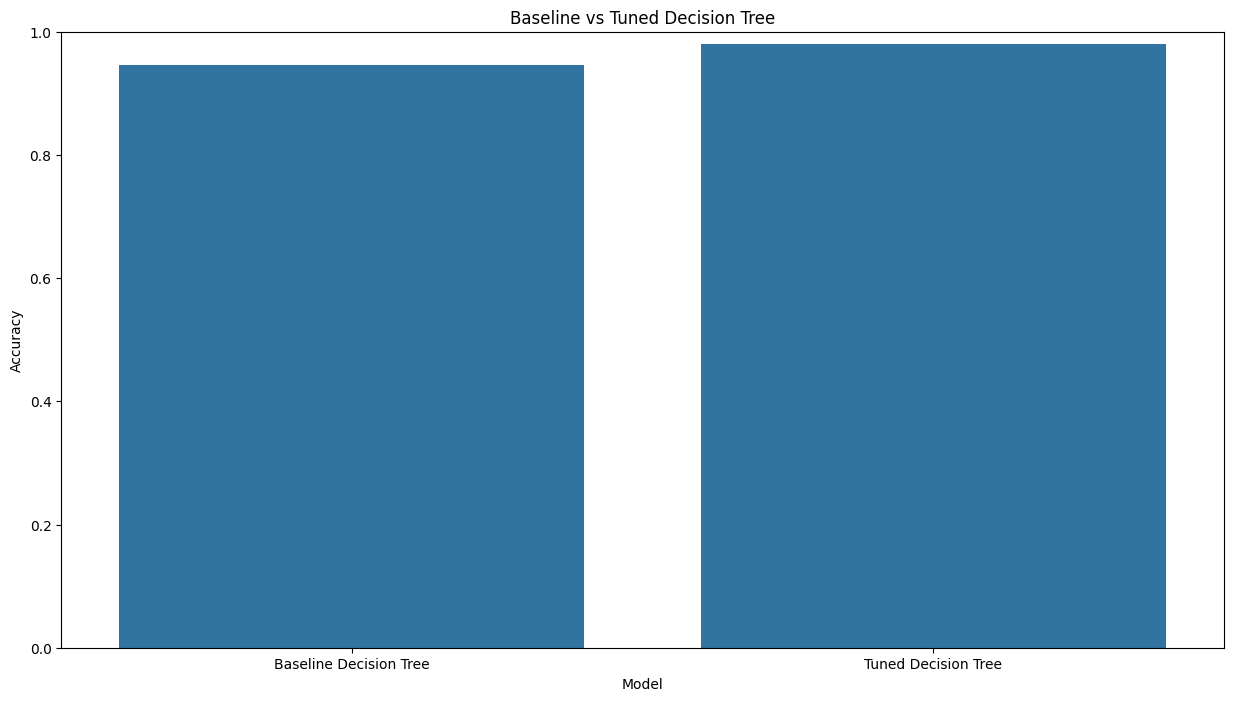

In [40]:
plt.figure(figsize=(15,8))
sns.barplot(
    data=tuning_comparison,
    x="Model",
    y="Accuracy"
)
plt.title("Baseline vs Tuned Decision Tree")
plt.ylim(0,1)
plt.show()

# Visualising the final decision tree

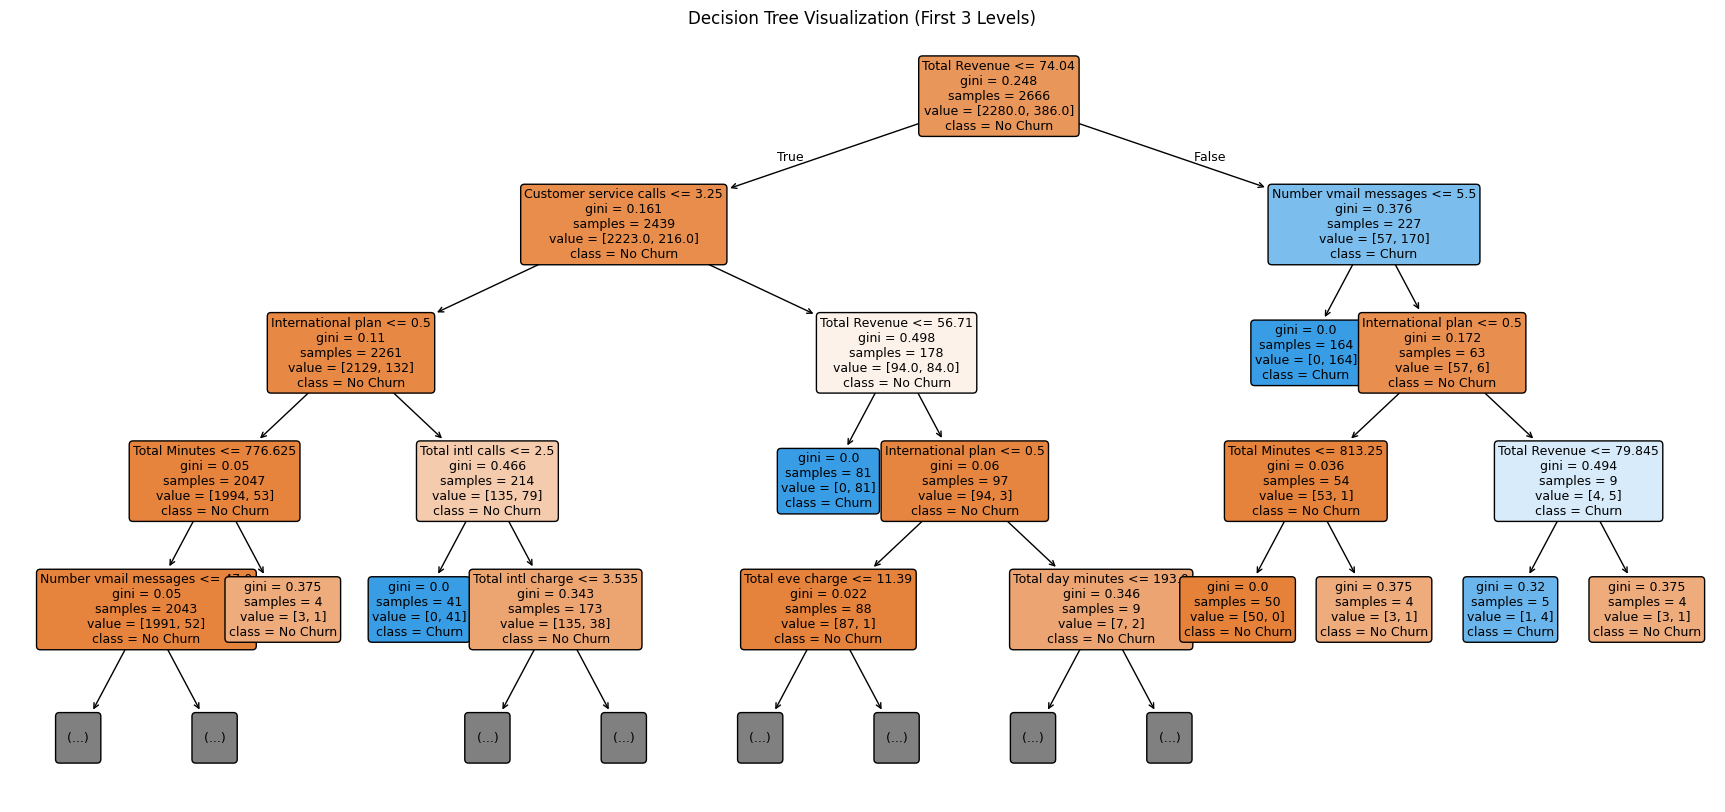

In [42]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22,10))

plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=["No Churn","Churn"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=9
)

plt.title("Decision Tree Visualization (First 3 Levels)")
plt.show()

# Pipeline

In [43]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", DecisionTreeClassifier(**grid_search.best_params_, random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=4,
                                        random_state=42))])

# Model Serialization
(means to save the model so that there is no need to re-train the model again and again)

In [44]:
import joblib
joblib.dump(pipeline, "best_model.pkl")
print("Pipeline saved successfully.")

Pipeline saved successfully.


# Load the saved model

In [45]:
loaded_pipeline = joblib.load("best_model.pkl")
print("Pipeline loaded successfully.")

Pipeline loaded successfully.


# Model Inference
( it is the process of using the trained model to make prediction on test data )

In [48]:
sample_customer = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample_customer)
probability = loaded_pipeline.predict_proba(sample_customer)

print("Prediction :", prediction[0])
print("Prediction Probabilities :", probability)

Prediction : True
Prediction Probabilities : [[0. 1.]]


In [50]:
sample_customer = X_test.iloc[[0]]

display(sample_customer)

prediction = loaded_pipeline.predict(sample_customer)

if prediction[0] == 1:
    print("⚠️ Customer is likely to Churn")
else:
    print("✅ Customer is likely to Stay")

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
717,161.0,415,0,0,0,191.9,113.0,32.62,70.9,87.0,...,False,False,False,False,False,False,False,False,True,False


⚠️ Customer is likely to Churn


In [49]:
sample_customer = X_test.iloc[[1]]

prediction = loaded_pipeline.predict(sample_customer)
probability = loaded_pipeline.predict_proba(sample_customer)

print("Prediction :", prediction[0])
print("Prediction Probabilities :", probability)

Prediction : False
Prediction Probabilities : [[0.97498774 0.02501226]]


In [51]:
sample_customer = X_test.iloc[[1]]

display(sample_customer)

prediction = loaded_pipeline.predict(sample_customer)

if prediction[0] == 1:
    print("⚠️ Customer is likely to Churn")
else:
    print("✅ Customer is likely to Stay")

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
2053,87.0,408,0,0,0,185.8,119.0,31.59,192.3,83.0,...,False,False,False,False,False,False,False,False,False,False


✅ Customer is likely to Stay
